# Lab 5
Image filtering and sharpening using the parrot image.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#  locations of parrot image
PARROT_CANDIDATES = [
    "parrot.jpg",
    "pdf_imgs/parrot.jpg",
    "lab 5/parrot.jpg",
    "lab 5/pdf_imgs/parrot.jpg",
]

# Function to load parrot image 
def load_parrot(mode="color"):
    # Choose reading mode
    flag = cv2.IMREAD_COLOR if mode == "color" else cv2.IMREAD_GRAYSCALE
    
    # Try all possible paths
    for path in PARROT_CANDIDATES:
        image = cv2.imread(path, flag)
        
        if image is not None:  # If image found
            if mode == "color":
                # Convert BGR (OpenCV) to RGB (Matplotlib)
                return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            return image  # Return grayscale image
    
    # If image not found in any path
    raise FileNotFoundError("Could not find parrot.jpg in Lab 5 paths.")


# Function to display multiple images
def show_images(images, titles, figsize=(15, 5), cmap=None):
    plt.figure(figsize=figsize)  # Set figure size
    
    for i, (img, title) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)  # Create subplot
        
        # If grayscale image
        if img.ndim == 2:
            plt.imshow(img, cmap=("gray" if cmap is None else cmap))
        else:
            plt.imshow(img)  # Color image
        
        plt.title(title)  # Set title
        plt.axis("off")   # Hide axis
    
    plt.tight_layout()  # Adjust spacing
    plt.show()          # Display images

# Task 1: Unsharp Masking
Apply unsharp masking to the parrot image.


[ WARN:0@2.147] global loadsave.cpp:278 findDecoder imread_('parrot.jpg'): can't open/read file: check file path/integrity


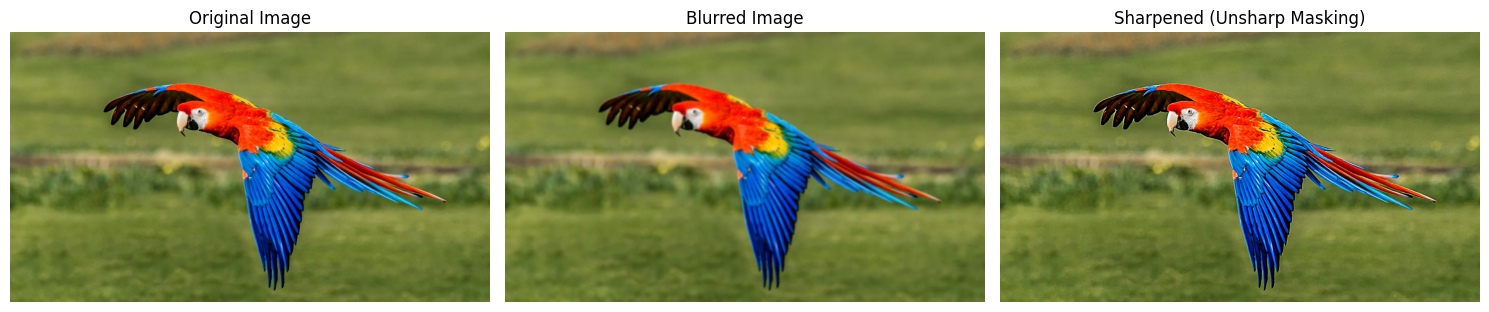

In [3]:
# Load parrot image in color
image = load_parrot(mode="color")

sigma = 2      # Gaussian blur strength
amount = 1.5   # Sharpening intensity

# Convert image to float range [0,1]
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Unsharp Masking 
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Show original, blurred, and sharpened images
show_images(
    [image_float, blurred, sharpened],
    ["Original Image", "Blurred Image", "Sharpened (Unsharp Masking)"]
)

## Assessment Task 1
Convolve an image with a 7x7 box filter.


[ WARN:0@656.983] global loadsave.cpp:278 findDecoder imread_('parrot.jpg'): can't open/read file: check file path/integrity


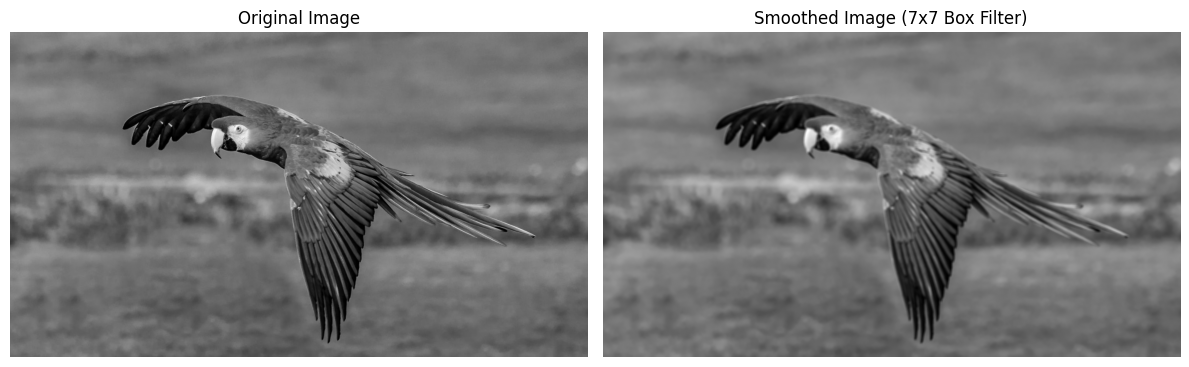

In [ ]:
# Load parrot image in grayscale
img3 = load_parrot(mode="gray")

# Create 7x7 averaging (box) filter kernel
kernel = np.ones((7, 7), np.float32) / 49  # Normalize by 49 (7*7)

# Apply filter using convolution
smoothed_box = cv2.filter2D(img3, -1, kernel)

# Display and smoothed images
show_images(
    [img3, smoothed_box],
    ["Original Image", "Smoothed Image (7x7 Box Filter)"],
    figsize=(12, 5),
    cmap="gray"  # Show as grayscale
)

# Task 2: Gaussian Filter Comparison
Apply a 5x5 Gaussian filter and a 21x21 Gaussian filter.


[ WARN:0@740.532] global loadsave.cpp:278 findDecoder imread_('parrot.jpg'): can't open/read file: check file path/integrity


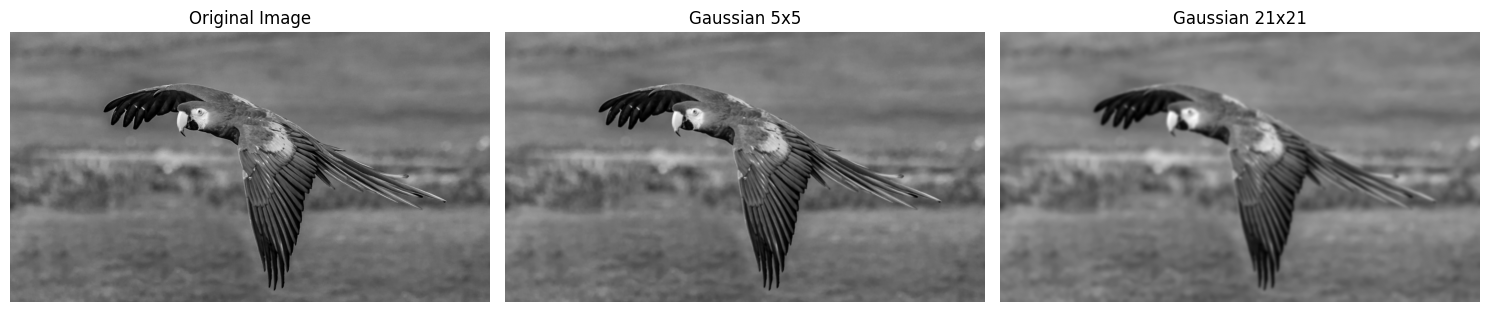

In [9]:
# Load parrot image in grayscale
img2 = load_parrot(mode="gray")

# Apply Gaussian blur with small kernel 
gauss_5 = cv2.GaussianBlur(img2, (5, 5), 0)

# Apply Gaussian blur with large kernel 
gauss_21 = cv2.GaussianBlur(img2, (21, 21), 0)

# Display original and blurred images
show_images(
    [img2, gauss_5, gauss_21],
    ["Original Image", "Gaussian 5x5", "Gaussian 21x21"],
    figsize=(15, 5),
    cmap="gray"  # Display as grayscale
)

## Assessment Task 3

Apply Laplacian sharpening and show original, Laplacian, and sharpened results.


[ WARN:0@764.333] global loadsave.cpp:278 findDecoder imread_('parrot.jpg'): can't open/read file: check file path/integrity


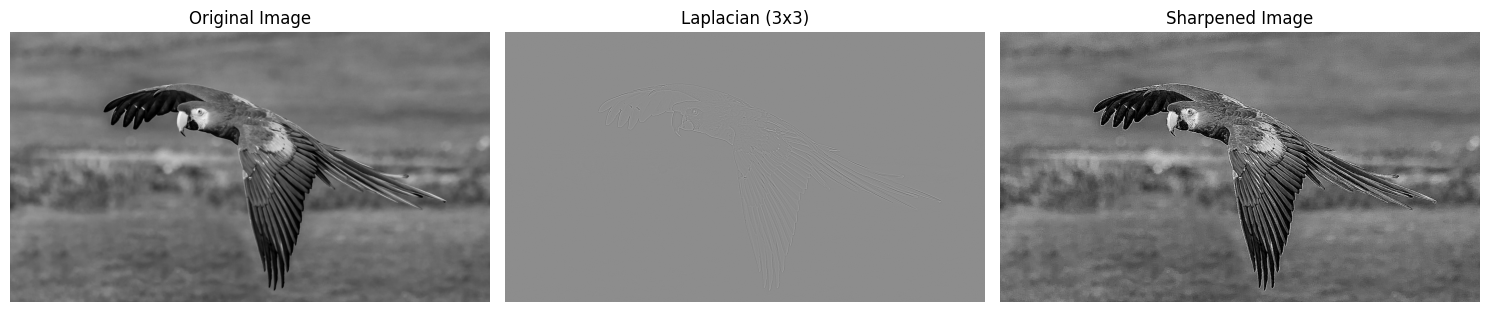

In [10]:
# Load parrot image in grayscale
img4 = load_parrot(mode="gray")

# Convert image to float range [0,1]
image_float = img4.astype(np.float32) / 255.0

# Apply Laplacian operator (edge detection)
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)

# Sharpen image using: original - Laplacian
sharpened_laplacian = np.clip(image_float - laplacian, 0, 1)

# Display original, Laplacian edges, and sharpened image
show_images(
    [image_float, laplacian, sharpened_laplacian],
    ["Original Image", "Laplacian (3x3)", "Sharpened Image"],
    cmap="gray"  # Show as grayscale
)